# Food Insecurity Phases Optimization and Analytics

### First Notebook: Data Preparation and Exploratory Data Analysis

This project focuses on optimizing humanitarian resource allocation based on population distributions across standardized food insecurity phases. It uses country-level data segmented by severity levels (Phase 1 to 5, including aggregated categories such as 3+) to support decision-making under constraints.

The dataset contains population counts by country, phase, and scenario type (current and projected), enabling structured comparison of different allocation contexts. Each record represents a population segment associated with a specific level of food insecurity severity.

The objective of this project is to prepare and structure the data in a way that makes it suitable for optimization models aimed at prioritizing and allocating limited humanitarian resources efficiently across countries and severity levels.

Data preparation focuses on ensuring consistency of phase distributions, validating population aggregates, and structuring inputs required for downstream optimization. Exploratory data analysis is used to understand the distribution of populations across phases and to identify key patterns relevant for allocation decisions.

The overall goal is to transform raw population-phase data into a clean and structured dataset that can directly support optimization models for humanitarian decision-making under resource constraints.

**Author:** J-F J  
**Date:** April 2026  
**Dataset:** Food Insecurity Phase Dataset (country-level population distribution by phase and scenario type)

## 1.1-Data Loading and Overview

In [1]:
import pandas as pd

# File path (Kaggle uploaded dataset)
file_path = "/kaggle/input/datasets/jfjutras07/food-insecurity/Food_Insecurity.csv"

# Load dataset
df = pd.read_csv(file_path)

# Preview
display(df.head())
display(df.tail())
df.info()

# Clone the public GitHub repository "jfj-utils"
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

# Add to path
import sys
sys.path.append("/kaggle/working/jfj-utils")

,Date of analysis,Country,Total country population,Validity period,From,To,Phase,Number,Percentage
0,Oct 2025,AFG,48595631,current,2025-09-01,2025-10-31,all,48595631,1.00
1,Oct 2025,AFG,48595631,current,2025-09-01,2025-10-31,3+,13775635,0.28
2,Oct 2025,AFG,48595631,current,2025-09-01,2025-10-31,1,14693763,0.30
3,Oct 2025,AFG,48595631,current,2025-09-01,2025-10-31,2,20126236,0.41
4,Oct 2025,AFG,48595631,current,2025-09-01,2025-10-31,3,10910077,0.22


,Date of analysis,Country,Total country population,Validity period,From,To,Phase,Number,Percentage
786,Oct 2020,ZWE,15557469,first projection,2021-01-01,2021-03-31,1,3221153,0.33
787,Oct 2020,ZWE,15557469,first projection,2021-01-01,2021-03-31,2,3104734,0.32
788,Oct 2020,ZWE,15557469,first projection,2021-01-01,2021-03-31,3,2611638,0.27
789,Oct 2020,ZWE,15557469,first projection,2021-01-01,2021-03-31,4,768594,0.08
790,Oct 2020,ZWE,15557469,first projection,2021-01-01,2021-03-31,5,0,0.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date of analysis          791 non-null    object 
 1   Country                   791 non-null    object 
 2   Total country population  791 non-null    int64  
 3   Validity period           791 non-null    object 
 4   From                      791 non-null    object 
 5   To                        791 non-null    object 
 6   Phase                     791 non-null    object 
 7   Number                    791 non-null    int64  
 8   Percentage                791 non-null    float64
dtypes: float64(1), int64(2), object(6)
memory usage: 55.7+ KB
Cloning into 'jfj-utils'...
remote: Enumerating objects: 3527, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (188/188), done.
remote: Total 3527 (delta 231), reused 99 (delta 99), pack-r

### Column Descriptions

| Column | Description |
|--------|-------------|
| Date of analysis | Reference date when the data snapshot was produced |
| Country | Country code representing the geographic unit |
| Total country population | Total population of the country (baseline reference) |
| Validity period | Type of scenario (e.g., current situation or projection scenario) |
| From | Start date of the validity period |
| To | End date of the validity period |
| Phase | Food insecurity phase (1 = minimal risk, 5 = extreme severity, 3+ = aggregated severe levels) |
| Number | Number of people in the given phase |
| Percentage | Share of the total country population in the given phase |

In [2]:
from eda.describe_structure import describe_structure
describe_structure(df)


=== Numeric Columns ===

                          count          mean           std  min         25%  \
Total country population  791.0  3.260204e+07  5.174468e+07  0.0  5625874.00   
Number                    791.0  6.983528e+06  1.709212e+07  0.0   189627.50   
Percentage                791.0  3.129962e-01  3.386335e-01  0.0        0.03   

                                  50%          75%          max  
Total country population  14744861.00  32244165.00  256774226.0  
Number                     1642143.00   6334241.50  217933705.0  
Percentage                       0.18         0.44          1.0  

=== Boolean Columns ===

Empty DataFrame
Columns: []
Index: []

=== Categorical Columns ===

                  unique_values     most_frequent  \
Date of analysis           20.0          Nov 2025   
Validity period             3.0  first projection   
Phase                       7.0                 1   

                                                  all_unique_values  \
Date of ana

The dataset provides a structured view of population distribution across food insecurity phases at the country level. Each record represents a population segment classified by severity level (Phase 1 to 5, including aggregated severe categories such as 3+), along with a corresponding scenario type (current or projected).

The data is complete with no missing values and includes 791 observations across 52 countries. It contains a mix of numerical and categorical variables, with population counts and percentages describing the distribution of individuals across food insecurity phases.

The phase variable includes seven distinct categories (1, 2, 3, 4, 5, 3+, and all), capturing both granular and aggregated representations of food insecurity severity. The dataset also includes total country population figures, allowing phase-level values to be interpreted in relative terms.

Overall, the dataset is well-structured and suitable for analytical processing. It provides a consistent basis for understanding how populations are distributed across severity levels, forming a foundation for subsequent optimization modeling focused on humanitarian resource allocation.

## 1.2-Data Cleaning and Transforming

### Period Filtering

In [3]:
# Filter dataset to a common time window (aligned periods across countries)

# Keep only current scenario
df_current = df[df["Validity period"] == "current"].copy()

# Convert date columns to datetime format for filtering
df_current["From"] = pd.to_datetime(df_current["From"])
df_current["To"] = pd.to_datetime(df_current["To"])

# Define target time window (example: Oct–Dec 2025)
start_date = "2025-10-01"
end_date = "2025-12-31"

# Filter rows fully contained within the selected time window
df_filtered = df_current[
    (df_current["From"] >= start_date) &
    (df_current["To"] <= end_date)
].copy()

# Optional: remove aggregated phase "3+" to keep only detailed phases
df_filtered = df_filtered[df_filtered["Phase"] != "3+"].copy()

# Check number of countries retained
print("Number of countries:", df_filtered["Country"].nunique())

# Preview result
display(df_filtered.sort_values(["Country", "From", "Phase"]))

Number of countries: 16


,Date of analysis,Country,Total country population,Validity period,From,To,Phase,Number,Percentage
58,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,1,2133087,0.77
59,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,2,447323,0.16
60,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,3,188147,0.07
61,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,4,2960,0.00
62,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,5,0,0.00
...,...,...,...,...,...,...,...,...,...
682,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,2,1171968,0.18
683,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,3,288383,0.04
684,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,4,0,0.00
685,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,5,0,0.00


### Total Validating

In [4]:
# Validate totals on filtered dataset (aligned time window)

# Separate total population ("all") and detailed phases (1–5)
df_all = df_filtered[df_filtered["Phase"] == "all"].copy()
df_phases = df_filtered[df_filtered["Phase"].isin(["1", "2", "3", "4", "5"])].copy()

# Define grouping keys (country + time window)
group_cols = ["Country", "From", "To"]

# Sum population across phases 1–5
phases_sum = (
    df_phases
    .groupby(group_cols)["Number"]
    .sum()
    .reset_index()
    .rename(columns={"Number": "sum_phases"})
)

# Extract total population ("all")
all_sum = (
    df_all
    .groupby(group_cols)["Number"]
    .first()
    .reset_index()
    .rename(columns={"Number": "total_all"})
)

# Merge both datasets
df_validation = pd.merge(phases_sum, all_sum, on=group_cols, how="inner")

# Compute difference
df_validation["difference"] = df_validation["sum_phases"] - df_validation["total_all"]

# Validation flag (tolerance = 1 person)
df_validation["is_valid"] = df_validation["difference"].abs() <= 1

# Display results
display(df_validation.sort_values(["Country"]))

,Country,From,To,sum_phases,total_all,difference,is_valid
0,BEN,2025-10-01,2025-12-31,2771517,2771518,-1,True
1,CIV,2025-10-01,2025-12-31,24801516,24801516,0,True
2,CMR,2025-10-01,2025-12-31,29414764,29414764,0,True
3,CPV,2025-10-01,2025-12-31,513998,513997,1,True
4,GHA,2025-10-01,2025-12-31,34378759,34378759,0,True
5,GIN,2025-10-01,2025-12-31,12414765,12414765,0,True
6,LBR,2025-10-01,2025-12-31,5625874,5625874,0,True
7,MLI,2025-10-01,2025-12-31,25568962,25568962,0,True
8,MRT,2025-10-01,2025-12-31,5606796,5606796,0,True
9,NER,2025-10-01,2025-12-31,28095491,27038336,1057155,False


In [5]:
# Keep only countries where phase totals match the reported total population.
# This ensures data consistency for the optimization example. In a real-world
# humanitarian context, we would not exclude inconsistent countries, but instead
# investigate and correct the data to avoid omitting populations that may be at risk.

# Identify valid countries
df_valid_countries = df_validation[df_validation["is_valid"]]["Country"]

# Filter dataset
df_filtered = df_filtered[df_filtered["Country"].isin(df_valid_countries)].copy()

# Check result
print("Number of countries after validation:", df_filtered["Country"].nunique())
display(df_filtered.sort_values(["Country", "From", "Phase"]))

Number of countries after validation: 15


,Date of analysis,Country,Total country population,Validity period,From,To,Phase,Number,Percentage
58,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,1,2133087,0.77
59,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,2,447323,0.16
60,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,3,188147,0.07
61,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,4,2960,0.00
62,Nov 2025,BEN,13224860,current,2025-10-01,2025-12-31,5,0,0.00
...,...,...,...,...,...,...,...,...,...
682,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,2,1171968,0.18
683,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,3,288383,0.04
684,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,4,0,0.00
685,Nov 2025,TGO,8866375,current,2025-10-01,2025-12-31,5,0,0.00


## 1.3-Severity-Oriented EDA for Resource Allocation

The objective of this section is to construct decision-ready indicators that balance both the scale of affected populations and the severity of food insecurity, in order to better inform resource allocation strategies.

### Aggregate Population by Country and Phase

In [6]:
# Aggregate population by country and phase
df_phases = df_filtered[df_filtered["Phase"].isin(["1", "2", "3", "4", "5"])]

df_country = (
    df_phases
    .groupby(["Country", "Phase"])["Number"]
    .sum()
    .unstack(fill_value=0)
)

# Ensure all phase columns exist
for phase in ["1", "2", "3", "4", "5"]:
    if phase not in df_country.columns:
        df_country[phase] = 0

df_country = df_country.reset_index()

### Compute Critical Metrics

In [7]:
# Total population (from phase "all")
df_total = (
    df_filtered[df_filtered["Phase"] == "all"]
    .groupby("Country")["Number"]
    .first()
    .reset_index()
    .rename(columns={"Number": "total_population"})
)

# Merge
df_country = df_country.merge(df_total, on="Country", how="left")

# Critical population (Phase 3–5)
df_country["critical_pop"] = (
    df_country["3"] + df_country["4"] + df_country["5"]
)

# Critical ratio
df_country["critical_ratio"] = (
    df_country["critical_pop"] / df_country["total_population"]
)

### Build Hybrid Priority Score

In [8]:
# Hybrid score: combines severity (ratio) and scale (absolute population)
df_country["hybrid_score"] = (
    df_country["critical_ratio"] * df_country["critical_pop"]
)

### Rank Countries by Priority

In [9]:
# Ranking by hybrid score
df_country = df_country.sort_values(
    by="hybrid_score", ascending=False
)

display(df_country)

,Country,1,2,3,4,5,total_population,critical_pop,critical_ratio,hybrid_score
9,NGA,104204933,86515838,26355367,857567,0,217933705,27212934,0.124868,3.398023e+06
10,PSE,0,475345,989840,507015,103800,2076000,1600655,0.771028,1.234150e+06
2,CMR,20099416,6194078,2871964,249306,0,29414764,3121270,0.106112,3.312053e+05
13,TCD,12227264,3915887,1831960,95621,0,18070731,1927581,0.106669,2.056125e+05
5,GIN,8295152,2638957,1426708,53948,0,12414765,1480656,0.119266,1.765915e+05
12,SLE,5340030,2739053,933530,65078,0,9077691,998608,0.110007,1.098537e+05
4,GHA,27884956,4932580,1489038,72185,0,34378759,1561223,0.045412,7.089893e+04
1,CIV,20438045,3330136,1023636,9699,0,24801516,1033335,0.041664,4.305306e+04
6,LBR,3950954,1256707,418213,0,0,5625874,418213,0.074337,3.108888e+04
7,MLI,22075035,2638287,824823,30817,0,25568962,855640,0.033464,2.863315e+04


The analysis identifies clear differences in the distribution and intensity of food insecurity across countries by combining both the number of people in critical phases (3–5) and their share of the total population into a single hybrid metric.

Nigeria ranks as the highest priority due to the very large number of individuals affected, resulting in the largest overall impact. Palestine also emerges as a key priority, driven by a very high concentration of its population in critical conditions. Countries such as Cameroon and Chad follow as important targets, reflecting a combination of significant population size and notable levels of severity. Overall, the results provide a structured and actionable prioritization of countries, directly supporting data-driven humanitarian resource allocation decisions.

### Top Countries by Hybrid Priority Score

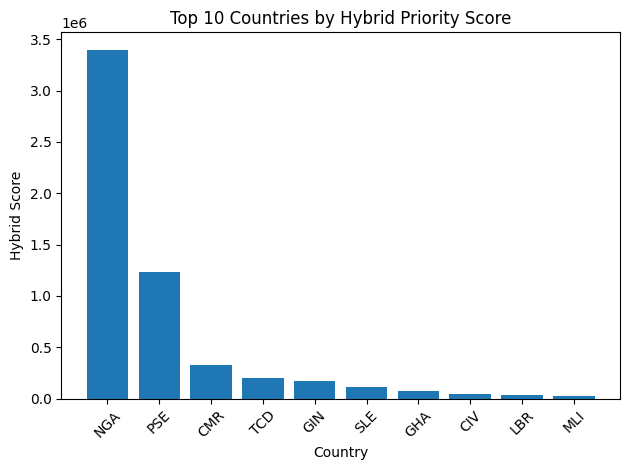

In [10]:
import matplotlib.pyplot as plt

# Top 10 countries
top_10 = df_country.head(10)

plt.figure()
plt.bar(top_10["Country"], top_10["hybrid_score"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Hybrid Priority Score")
plt.xlabel("Country")
plt.ylabel("Hybrid Score")
plt.tight_layout()
plt.show()

### Critical Population vs Critical Ratio

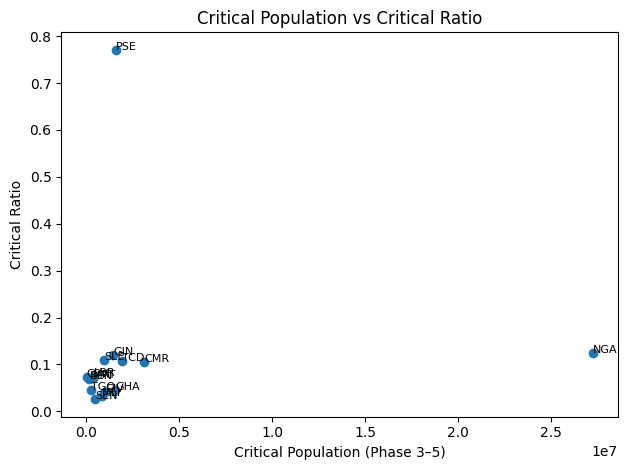

In [11]:
plt.figure()

plt.scatter(
    df_country["critical_pop"],
    df_country["critical_ratio"]
)

# Annotate countries
for i, row in df_country.iterrows():
    plt.text(
        row["critical_pop"],
        row["critical_ratio"],
        row["Country"],
        fontsize=8
    )

plt.title("Critical Population vs Critical Ratio")
plt.xlabel("Critical Population (Phase 3–5)")
plt.ylabel("Critical Ratio")
plt.tight_layout()
plt.show()

### Distribution of Population by Phase

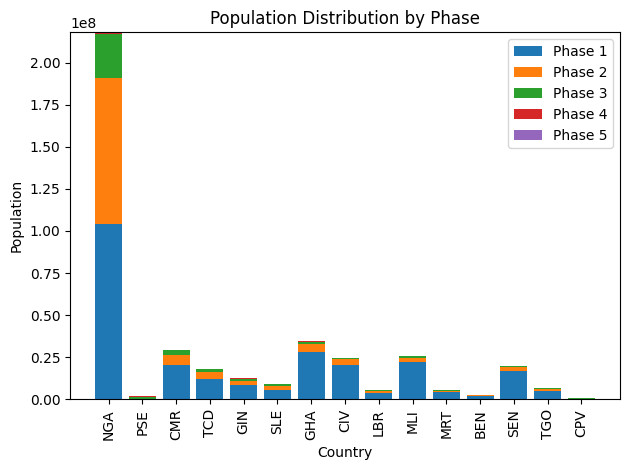

In [12]:
# Sort for readability
df_plot = df_country.sort_values("hybrid_score", ascending=False)

phases = ["1", "2", "3", "4", "5"]

bottom = None

plt.figure()

for phase in phases:
    if bottom is None:
        plt.bar(df_plot["Country"], df_plot[phase], label=f"Phase {phase}")
        bottom = df_plot[phase].copy()
    else:
        plt.bar(
            df_plot["Country"],
            df_plot[phase],
            bottom=bottom,
            label=f"Phase {phase}"
        )
        bottom += df_plot[phase]

plt.xticks(rotation=90)
plt.title("Population Distribution by Phase")
plt.xlabel("Country")
plt.ylabel("Population")
plt.legend()
plt.tight_layout()
plt.show()

### Critical Ratio Ranking

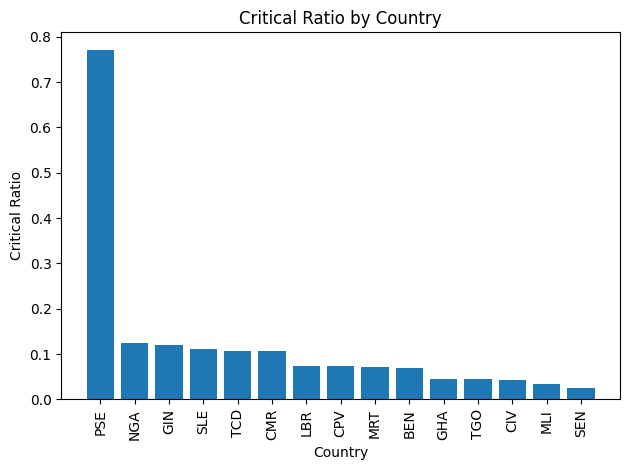

In [13]:
df_ratio = df_country.sort_values("critical_ratio", ascending=False)

plt.figure()
plt.bar(df_ratio["Country"], df_ratio["critical_ratio"])
plt.xticks(rotation=90)
plt.title("Critical Ratio by Country")
plt.xlabel("Country")
plt.ylabel("Critical Ratio")
plt.tight_layout()
plt.show()

## 1.4-Data Export

In [14]:
# Export final dataset for optimization notebook
output_path = "/kaggle/working/food_insecurity_clean.csv"

df_country.to_csv(output_path, index=False)

print("Dataset exported to:", output_path)

Dataset exported to: /kaggle/working/food_insecurity_clean.csv


## 1.5-Summary - Notebook 1

| Step | Component                 | Description                                                                                     | Key Output                                      |
| ---- | ------------------------- | ----------------------------------------------------------------------------------------------- | ----------------------------------------------- |
| 1.1  | Data Loading & Overview   | Loaded dataset and reviewed structure, variables, and distributions                             | Initial structured dataset                      |
| 1.2  | Data Cleaning & Filtering | Filtered current scenario, aligned time window, removed aggregated phases, and validated totals | Clean and consistent dataset ready for analysis |
| 1.3  | Feature Engineering       | Aggregated data at country level and computed critical population and ratio                     | `critical_pop`, `critical_ratio`                |
| 1.3  | Hybrid Scoring            | Built a severity-scale combined metric for prioritization                                       | `hybrid_score`                                  |
| 1.3  | Ranking                   | Ranked countries based on hybrid score to identify priority targets                             | Ordered priority list                           |
| 1.4  | Data Visualization        | Created decision-oriented visualizations to support interpretation                              | Actionable visual insights                      |
